<a href="https://colab.research.google.com/github/SholbanDongak/colab/blob/main/9_mixed__models_introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проблема и пример I: Завышения коэффициентов

Изучаем влияние инвестиций в маркетинг на продажи. Данные по 10 компаниям за 5 периодов.

Сильные компании имеют стабильно высокие продажи и большие маркетинговые бюджеты. Наивная регрессия приписывает всю межфирменную разницу маркетингу, завышая его эффект.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

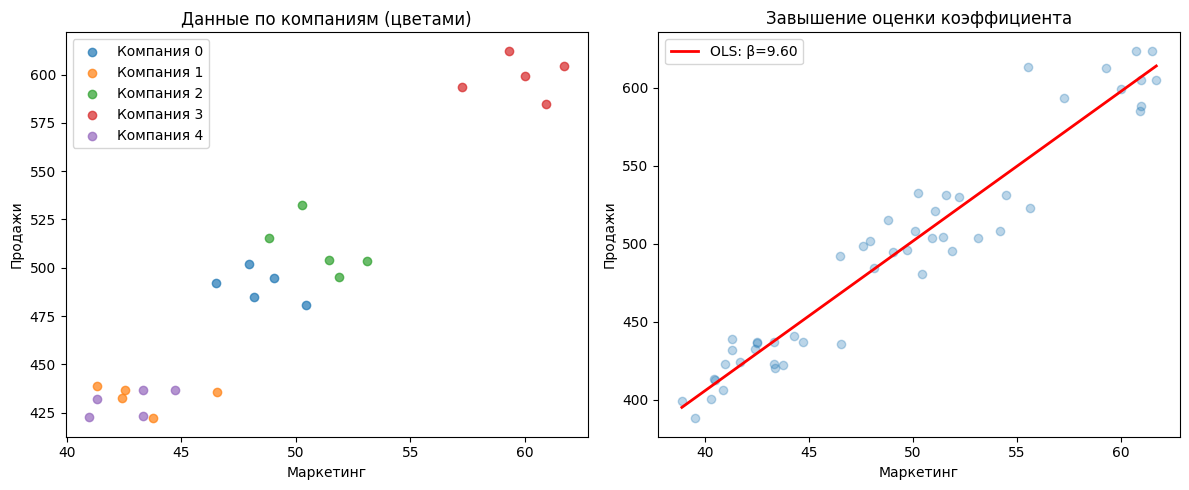

Истинный коэффициент: 0.50
OLS оценка: 9.60
Завышение в 19.2 раз


In [ ]:
# Генерация данных
np.random.seed(42)
n_companies = 10
periods = 5
n_obs = n_companies * periods

# Базовые уровни компаний (ненаблюдаемое качество)
company_effects = np.random.normal(50, 20, n_companies)

data = []
for i in range(n_companies):
    base_sales = 200 + company_effects[i] * 5  # Базовые продажи
    base_marketing = 20 + company_effects[i] * 0.5  # Базовый маркетинг

    for t in range(periods):
        marketing = base_marketing + np.random.normal(0, 2)
        sales = base_sales + 0.5 * (marketing - base_marketing) + np.random.normal(0, 10)
        data.append({'company': i, 'period': t, 'marketing': marketing, 'sales': sales})

df1 = pd.DataFrame(data)

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for company in range(min(5, n_companies)):
    company_data = df1[df1['company'] == company]
    plt.scatter(company_data['marketing'], company_data['sales'],
               label=f'Компания {company}', alpha=0.7)
plt.xlabel('Маркетинг')
plt.ylabel('Продажи')
plt.title('Данные по компаниям (цветами)')
plt.legend()

plt.subplot(1, 2, 2)
# Наивная регрессия
X = df1[['marketing']]
X = sm.add_constant(X)
y = df1['sales']
model_naive = sm.OLS(y, X).fit()

x_range = np.linspace(df1['marketing'].min(), df1['marketing'].max(), 100)
y_naive = model_naive.params[0] + model_naive.params[1] * x_range

plt.scatter(df1['marketing'], df1['sales'], alpha=0.3)
plt.plot(x_range, y_naive, 'r-', linewidth=2,
         label=f'OLS: β={model_naive.params[1]:.2f}')

plt.xlabel('Маркетинг')
plt.ylabel('Продажи')
plt.title('Завышение оценки коэффициента')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Истинный коэффициент: 0.50")
print(f"OLS оценка: {model_naive.params[1]:.2f}")
print(f"Завышение в {model_naive.params[1]/0.5:.1f} раз")

In [ ]:
print(f"Истинный коэффициент: 0.50")
print(f"OLS оценка: {model_naive.params[1]:.4f}")
print(f"Стандартная ошибка: {model_naive.bse[1]:.4f}")
print(f"t-статистика: {model_naive.tvalues[1]:.4f}")
print(f"p-value: {model_naive.pvalues[1]:.6f}")
print(f"95% доверительный интервал: [{model_naive.conf_int().iloc[1,0]:.3f}, {model_naive.conf_int().iloc[1,1]:.3f}]")
print(f"Завышение оценки: {model_naive.params[1]/0.5:.1f} раз")

Истинный коэффициент: 0.50
OLS оценка: 9.5953
Стандартная ошибка: 0.3831
t-статистика: 25.0484
p-value: 0.000000
95% доверительный интервал: [8.825, 10.366]
Завышение оценки: 19.2 раз


In [ ]:
from statsmodels.regression.mixed_linear_model import MixedLM
import scipy.stats as stats

In [ ]:
print(f"OLS модель:")
print(f"  Коэффициент: {model_naive.params[1]:.4f}")
print(f"  Стандартная ошибка: {model_naive.bse[1]:.4f}")
print(f"  t-статистика: {model_naive.tvalues[1]:.4f}")
print(f"  p-value: {model_naive.pvalues[1]:.6f}")

mixed_model = MixedLM.from_formula("sales ~ marketing", data=df1,
                                  groups=df1["company"]).fit()

print(f"\nСмешанная модель:")
print(f"  Коэффициент: {mixed_model.params['marketing']:.4f}")
print(f"  Стандартная ошибка: {mixed_model.bse['marketing']:.4f}")

t_stat_mixed = abs(mixed_model.params['marketing'] / mixed_model.bse['marketing'])
p_value_mixed = 2 * (1 - stats.t.cdf(t_stat_mixed, df=len(df1)-len(mixed_model.params)))
print(f"  t-статистика: {t_stat_mixed:.4f}")
print(f"  p-value: {p_value_mixed:.6f}")

print(f"\nСравнение:")
print(f"  Завышение коэффициента: {model_naive.params[1]/0.5:.2f} раз")


OLS модель:
  Коэффициент: 9.5953
  Стандартная ошибка: 0.3831
  t-статистика: 25.0484
  p-value: 0.000000

Смешанная модель:
  Коэффициент: 0.9121
  Стандартная ошибка: 0.9331
  t-статистика: 0.9775
  p-value: 0.333324

Сравнение:
  Завышение коэффициента: 19.19 раз


# Проблема и пример II: Занижение коэффициентов

Внутри каждой компании больше обучения приводит к росту производительности, но сильные межфирменные различия создают «шум», который маскирует истинный эффект обучения.

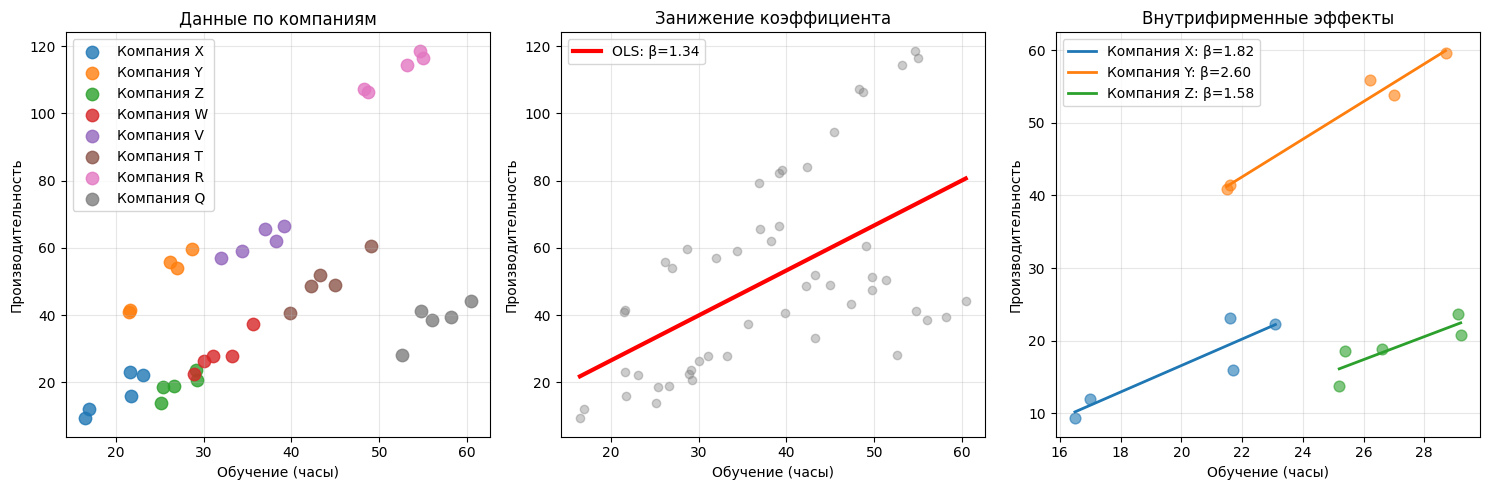


Результаты оценивания:
Истинный внутрифирменный коэффициент: 2.00
OLS оценка: 1.34
Занижение в 1.5 раза
R² модели: 0.306

Внутрифирменные коэффициенты:
Компания X: β = 1.82
Компания Y: β = 2.60
Компания Z: β = 1.58


In [ ]:
# Генерация данных для ЗАНИЖЕНИЯ коэффициентов
np.random.seed(123)
n_companies = 10
periods = 5

data = []
company_names = ['X', 'Y', 'Z', 'W', 'V', 'U', 'T', 'S', 'R', 'Q']

for i in range(n_companies):
    # Сильные различия между компаниями (фиксированные эффекты)
    company_effect = np.random.normal(0, 30)

    for t in range(periods):
        # Training варьируется вокруг среднего для компании
        base_training = 20 + i * 4  # Увеличивающийся базовый уровень
        training = base_training + (t - 2) * 2 + np.random.normal(0, 1)

        # СИЛЬНЫЙ внутрифирменный эффект (2.0) + межфирменные различия
        productivity = (50 + company_effect +  # Межфирменные различия
                       2.0 * (training - base_training) +  # Внутрифирменный эффект
                       np.random.normal(0, 2))

        data.append({
            'company': company_names[i],
            'period': t,
            'training': round(training, 1),
            'productivity': round(productivity, 1),
            'base_training': base_training
        })

df2 = pd.DataFrame(data)

# Вывод иллюстрационных данных для таблицы
#print("Иллюстрационные данные для слайда:")
#for company in ['X', 'Y', 'Z']:
#    comp_data = df2[df2['company'] == company]
#    training_vals = comp_data['training'].values.round(1)
#    productivity_vals = comp_data['productivity'].values.round(1)
#    print(f"Компания {company}: training = {list(training_vals)}, productivity = {list(productivity_vals)}")

# Визуализация
plt.figure(figsize=(15, 5))

# График 1: Данные по компаниям
plt.subplot(1, 3, 1)
for company in ['X', 'Y', 'Z', 'W', 'V', 'T', 'R', 'Q']:
    company_data = df2[df2['company'] == company]
    plt.scatter(company_data['training'], company_data['productivity'],
               label=f'Компания {company}', s=80, alpha=0.8)
plt.xlabel('Обучение (часы)')
plt.ylabel('Производительность')
plt.title('Данные по компаниям')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Наивная регрессия
plt.subplot(1, 3, 2)
X = df2[['training']]
X = sm.add_constant(X)
y = df2['productivity']
model_naive2 = sm.OLS(y, X).fit()

x_range = np.linspace(df2['training'].min(), df2['training'].max(), 100)
y_naive = model_naive2.params[0] + model_naive2.params[1] * x_range

plt.scatter(df2['training'], df2['productivity'], alpha=0.4, color='gray')
plt.plot(x_range, y_naive, 'r-', linewidth=3,
         label=f'OLS: β={model_naive2.params[1]:.2f}')
#plt.plot(x_range, 50 + 2.0*x_range, 'k--', linewidth=2,
#         label='Истинный внутрифирменный: β=2.0')
plt.xlabel('Обучение (часы)')
plt.ylabel('Производительность')
plt.title('Занижение коэффициента')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Внутрифирменные тренды
plt.subplot(1, 3, 3)
for company in ['X', 'Y', 'Z']:
    company_data = df2[df2['company'] == company]
    x_comp = company_data['training']
    y_comp = company_data['productivity']
    coeffs = np.polyfit(x_comp, y_comp, 1)
    x_range_comp = np.linspace(x_comp.min(), x_comp.max(), 10)
    plt.plot(x_range_comp, coeffs[0]*x_range_comp + coeffs[1],
             label=f'Компания {company}: β={coeffs[0]:.2f}', linewidth=2)

    plt.scatter(x_comp, y_comp, alpha=0.6, s=60)

plt.xlabel('Обучение (часы)')
plt.ylabel('Производительность')
plt.title('Внутрифирменные эффекты')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистические результаты
print(f"\nРезультаты оценивания:")
print(f"Истинный внутрифирменный коэффициент: 2.00")
print(f"OLS оценка: {model_naive2.params[1]:.2f}")
print(f"Занижение в {2.0/model_naive2.params[1]:.1f} раза")
print(f"R² модели: {model_naive2.rsquared:.3f}")

# Проверим внутрифирменные эффекты
print(f"\nВнутрифирменные коэффициенты:")
for company in ['X', 'Y', 'Z']:
    company_data = df2[df2['company'] == company]
    x_comp = company_data['training']
    y_comp = company_data['productivity']
    coeffs = np.polyfit(x_comp, y_comp, 1)
    print(f"Компания {company}: β = {coeffs[0]:.2f}")

In [ ]:
mixed_model = MixedLM.from_formula("productivity ~ training", data=df2,
                                  groups=df2["company"]).fit()

print(f"\nСмешанная модель:")
print(f"  Коэффициент: {mixed_model.params['training']:.4f}")
print(f"  Стандартная ошибка: {mixed_model.bse['training']:.4f}")


Смешанная модель:
  Коэффициент: 1.8458
  Стандартная ошибка: 0.1291


# Проблема и пример III. Эффект Симпсона: смена знака коэффициента

Изучаем влияние рабочих часов на удовлетворенность сотрудников. Данные по 8 компаниям за 5 периодов.

Внутри каждой компании: больше часов - меньше удовлетворенности.
Но между компаниями: успешные компании имеют больше часов И более довольных сотрудников.

Иллюстрационные данные для слайда:
Компания P: hours = [np.float64(34.0), np.float64(36.2), np.float64(35.5), np.float64(36.0), np.float64(33.7)], satisfaction = [np.float64(47.5), np.float64(42.0), np.float64(45.5), np.float64(43.5), np.float64(47.0)]
Компания Q: hours = [np.float64(37.5), np.float64(38.3), np.float64(37.9), np.float64(38.3), np.float64(38.7)], satisfaction = [np.float64(49.1), np.float64(50.1), np.float64(49.0), np.float64(51.5), np.float64(50.0)]
Компания R: hours = [np.float64(39.7), np.float64(39.0), np.float64(40.4), np.float64(42.4), np.float64(39.8)], satisfaction = [np.float64(56.8), np.float64(57.8), np.float64(56.2), np.float64(50.7), np.float64(56.7)]


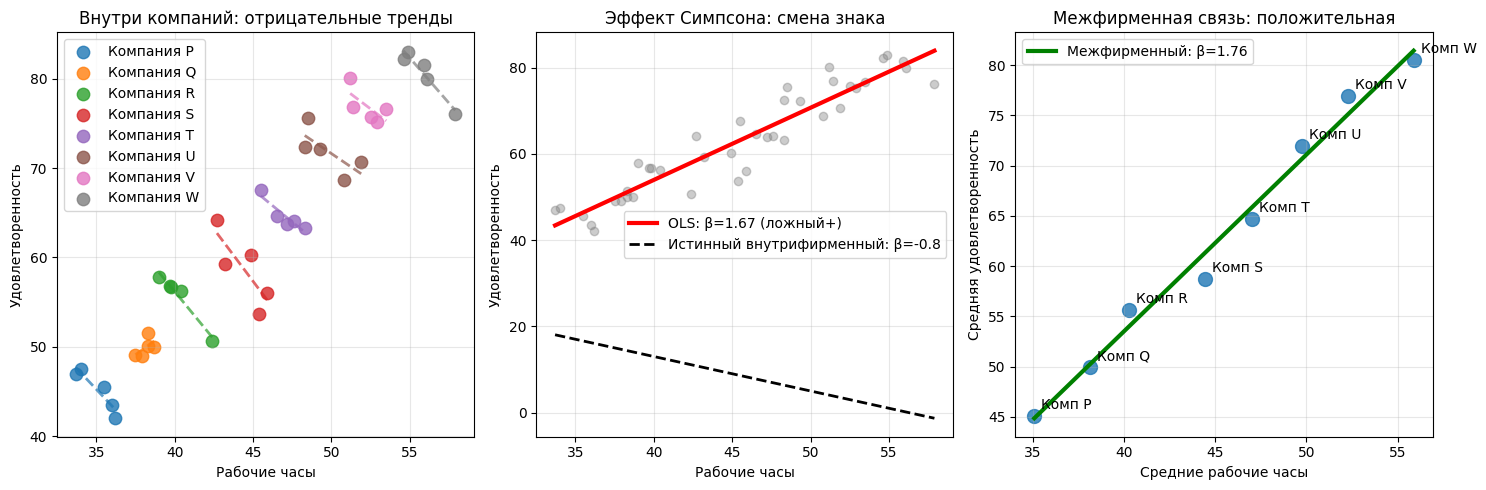


Результаты оценивания:
Истинный внутрифирменный коэффициент: -0.80
OLS оценка: 1.67
СМЕНА ЗНАКА! Отрицательный → положительный

Внутрифирменные коэффициенты:
Компания P: β = -1.87
Компания Q: β = 1.29
Компания R: β = -2.14

Межфирменный коэффициент (по средним): 1.76
R² модели OLS: 0.884


In [ ]:
np.random.seed(456)
n_companies = 8
periods = 5

data = []
company_names = ['P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W']

# РАЗВЕРНУТО: успешные компании имеют больше часов И выше удовлетворенность
company_base_hours = [35, 38, 41, 44, 47, 50, 53, 56]  # Увеличивающаяся нагрузка
company_base_satisfaction = [45, 50, 55, 60, 65, 70, 75, 80]  # ВОЗРАСТАЮЩЕЕ качество компаний

for i in range(n_companies):
    for t in range(periods):
        # Часы работы с небольшими колебаниями
        hours = company_base_hours[i] + np.random.uniform(-2, 2)

        # Внутри компании: больше часов → МЕНЬШЕ удовлетворенности (отрицательный эффект)
        satisfaction = (company_base_satisfaction[i] -
                       1.8 * (hours - company_base_hours[i]) +  # Отрицательный эффект внутри компании
                       np.random.normal(0, 1.5))

        data.append({
            'company': company_names[i],
            'period': t,
            'hours': round(hours, 1),
            'satisfaction': round(satisfaction, 1)
        })

df3 = pd.DataFrame(data)

# Вывод иллюстрационных данных для таблицы
print("Иллюстрационные данные для слайда:")
for company in ['P', 'Q', 'R']:
    comp_data = df3[df3['company'] == company]
    hours_vals = comp_data['hours'].values.round(1)
    satisfaction_vals = comp_data['satisfaction'].values.round(1)
    print(f"Компания {company}: hours = {list(hours_vals)}, satisfaction = {list(satisfaction_vals)}")

# Визуализация
plt.figure(figsize=(15, 5))

# График 1: Данные по компаниям с внутрифирменными трендами
plt.subplot(1, 3, 1)
for i, company in enumerate(['P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W']):
    company_data = df3[df3['company'] == company]
    plt.scatter(company_data['hours'], company_data['satisfaction'],
               label=f'Компания {company}', s=80, alpha=0.8)

    # Линии тренда внутри компаний
    x_comp = company_data['hours']
    y_comp = company_data['satisfaction']
    coeffs = np.polyfit(x_comp, y_comp, 1)
    x_range_comp = np.linspace(x_comp.min(), x_comp.max(), 10)
    plt.plot(x_range_comp, coeffs[0]*x_range_comp + coeffs[1],
             '--', alpha=0.7, linewidth=2)

plt.xlabel('Рабочие часы')
plt.ylabel('Удовлетворенность')
plt.title('Внутри компаний: отрицательные тренды')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Наивная регрессия (ложный положительный эффект)
plt.subplot(1, 3, 2)
X = df3[['hours']]
X = sm.add_constant(X)
y = df3['satisfaction']
model_naive3 = sm.OLS(y, X).fit()

x_range = np.linspace(df3['hours'].min(), df3['hours'].max(), 100)
y_naive = model_naive3.params[0] + model_naive3.params[1] * x_range

plt.scatter(df3['hours'], df3['satisfaction'], alpha=0.4, color='gray')
plt.plot(x_range, y_naive, 'r-', linewidth=3,
         label=f'OLS: β={model_naive3.params[1]:.2f} (ложный+)')
plt.plot(x_range, 45 - 0.8*x_range, 'k--', linewidth=2,
         label='Истинный внутрифирменный: β=-0.8')
plt.xlabel('Рабочие часы')
plt.ylabel('Удовлетворенность')
plt.title('Эффект Симпсона: смена знака')
plt.legend()
plt.grid(True, alpha=0.3)

# График 3: Межфирменное сравнение
plt.subplot(1, 3, 3)
company_means = df3.groupby('company').agg({
    'hours': 'mean',
    'satisfaction': 'mean'
}).reset_index()

plt.scatter(company_means['hours'], company_means['satisfaction'], s=100, alpha=0.8)

# Линия тренда для средних по компаниям
x_means = company_means['hours']
y_means = company_means['satisfaction']
coeffs_means = np.polyfit(x_means, y_means, 1)
x_range_means = np.linspace(x_means.min(), x_means.max(), 10)
plt.plot(x_range_means, coeffs_means[0]*x_range_means + coeffs_means[1],
         'g-', linewidth=3, label=f'Межфирменный: β={coeffs_means[0]:.2f}')

for i, row in company_means.iterrows():
    plt.annotate(f"Комп {row['company']}",
                (row['hours'], row['satisfaction']),
                xytext=(5, 5), textcoords='offset points')

plt.xlabel('Средние рабочие часы')
plt.ylabel('Средняя удовлетворенность')
plt.title('Межфирменная связь: положительная')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистические результаты
print(f"\nРезультаты оценивания:")
print(f"Истинный внутрифирменный коэффициент: -0.80")
print(f"OLS оценка: {model_naive3.params[1]:.2f}")
print(f"СМЕНА ЗНАКА! Отрицательный → положительный")

print(f"\nВнутрифирменные коэффициенты:")
for company in ['P', 'Q', 'R']:
    company_data = df3[df3['company'] == company]
    x_comp = company_data['hours']
    y_comp = company_data['satisfaction']
    coeffs = np.polyfit(x_comp, y_comp, 1)
    print(f"Компания {company}: β = {coeffs[0]:.2f}")

print(f"\nМежфирменный коэффициент (по средним): {coeffs_means[0]:.2f}")
print(f"R² модели OLS: {model_naive3.rsquared:.3f}")